# Q2 Customer Cohort Analysis

Tracking retention and revenue across the four cohorts that signed up between April and June. Source: `orders.parquet` · refreshed nightly via `dbt`.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# pink everything 🌸
pl.Config.set_tbl_rows(8)

polars.config.Config

In [2]:
df = pl.DataFrame({
    'order_id':     ['ord_8a32f1', 'ord_8a32f2', 'ord_8a32f3', 'ord_8a32f4', 'ord_8a32f5', 'ord_8a32f6'],
    'customer':     ['Mira Okafor', 'Renji Tanaka', 'Camila Rojas', 'Aiden Park', 'Sofía Lindgren', 'Devon Whittle'],
    'signup_month': ['2026-04', '2026-04', '2026-04', '2026-05', '2026-05', '2026-06'],
    'region':       ['EU-West', 'APAC', 'LATAM', 'NA-East', 'EU-North', 'NA-West'],
    'plan':         ['Studio', 'Studio', 'Solo', 'Team', 'Solo', 'Team'],
    'revenue':      [128.40, 214.00, 59.00, 312.50, None, 248.90],
})
df

order_id,customer,signup_month,region,plan,revenue
str,str,str,str,str,f64
"""ord_8a32f1""","""Mira Okafor""","""2026-04""","""EU-West""","""Studio""",128.4
"""ord_8a32f2""","""Renji Tanaka""","""2026-04""","""APAC""","""Studio""",214.0
"""ord_8a32f3""","""Camila Rojas""","""2026-04""","""LATAM""","""Solo""",59.0
"""ord_8a32f4""","""Aiden Park""","""2026-05""","""NA-East""","""Team""",312.5
"""ord_8a32f5""","""Sofía Lindgren""","""2026-05""","""EU-North""","""Solo""",null
"""ord_8a32f6""","""Devon Whittle""","""2026-06""","""NA-West""","""Team""",248.9


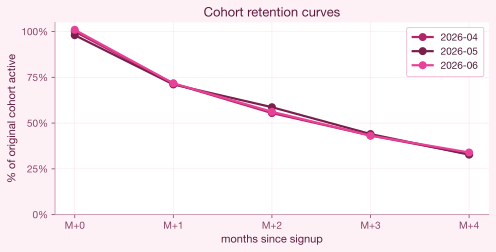

In [3]:
# cohort retention curves
rng = np.random.default_rng(7)
x = np.arange(5)
cohorts = {'2026-04': 1.00, '2026-05': 1.00, '2026-06': 1.00}
fig, ax = plt.subplots(figsize=(7, 3.6))
for label, start in cohorts.items():
    decay = np.array([1.0, 0.71, 0.56, 0.45, 0.34]) + rng.normal(0, 0.02, 5)
    ax.plot(x, decay, marker='o', label=label, linewidth=2.2, markersize=8)
ax.set_title('Cohort retention curves')
ax.set_xlabel('months since signup')
ax.set_ylabel('% of original cohort active')
ax.set_xticks(x); ax.set_xticklabels([f'M+{i}' for i in x])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

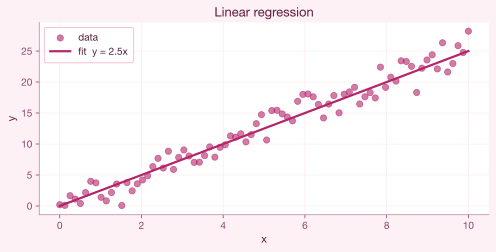

In [4]:
# scatter with regression line
rng = np.random.default_rng(0)
x = np.linspace(0, 10, 80)
y = 2.5 * x + rng.normal(0, 1.6, 80)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(x, y, alpha=0.6, s=40, label='data')
ax.plot(x, 2.5 * x, label='fit  y = 2.5x', linewidth=2.2)
ax.set_title('Linear regression')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
plt.show()